In [1]:
# Section 1: Import all required libraries and setup S3 configuration
# Run this first to ensure all dependencies are available

import os
import time
import pickle
import torch
import numpy as np
import pandas as pd
import json
import hashlib
from boto3.s3.transfer import TransferConfig
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.transforms import (
    ToPILImage, ToTensor, Normalize, Resize, 
    ColorJitter, RandomPerspective, Compose
)
from torchvision.io import read_image
import timm
import boto3
from botocore.exceptions import NoCredentialsError

print("All libraries imported successfully!")

# S3 Configuration - Update these with your actual AWS details
S3_BUCKET_NAME = 'vims-ngwos'  # Replace with your actual bucket name
S3_REGION = 'us-east-1'        # Replace with your region

# Initialize S3 client
try:
    s3_client = boto3.client('s3', region_name=S3_REGION)
    print(f"Connected to S3 bucket: {S3_BUCKET_NAME}")
except Exception as e:
    print(f"Warning: Could not connect to S3: {e}")
    s3_client = None

All libraries imported successfully!
Connected to S3 bucket: vims-ngwos


In [2]:
# Section 2: S3 helper functions for uploading and downloading files
# These functions handle file transfers to/from AWS S3

def upload_to_s3(local_file, s3_key):
    """Simple function to upload a file to S3"""
    if s3_client is None:
        print("S3 client not initialized, skipping upload")
        return False
    
    try:
        s3_client.upload_file(local_file, S3_BUCKET_NAME, s3_key)
        print(f"Uploaded {local_file} to s3://{S3_BUCKET_NAME}/{s3_key}")
        return True
    except Exception as e:
        print(f"Error uploading to S3: {e}")
        return False

def download_from_s3(s3_key, local_file):
    """Simple function to download a file from S3"""
    if s3_client is None:
        print("S3 client not initialized, skipping download")
        return False
    
    try:
        s3_client.download_file(S3_BUCKET_NAME, s3_key, local_file)
        print(f"Downloaded s3://{S3_BUCKET_NAME}/{s3_key} to {local_file}")
        return True
    except Exception as e:
        print(f"Error downloading from S3: {e}")
        return False

print("S3 helper functions loaded successfully!")

S3 helper functions loaded successfully!


In [ ]:
# Section 3: Dataset class for loading and transforming images with targets
# This handles image preprocessing, augmentation, and target scaling
class SafeDataset(torch.utils.data.Dataset):
    def __init__(self, mappings, input_img_size, model_config, scaler=None, training=True):  # FIXED: was 'init'
        self.image_paths = list(mappings.keys())
        self.targets = [mappings[path] for path in self.image_paths]
        self.training = training
        
        # Setup target scaling (normalization)
        if scaler is None:  # FIXED: was "if not scaler" which can raise ValueError on fitted scalers
            self.scaler = StandardScaler()
            self.targets_scaled = self.scaler.fit_transform(np.array(self.targets).reshape(-1, 1)).flatten()
        else:
            self.scaler = scaler
            self.targets_scaled = self.scaler.transform(np.array(self.targets).reshape(-1, 1)).flatten()
        
        # Setup image transformations
        transforms_list = [ToPILImage(), Resize((input_img_size, input_img_size))]
        
        if self.training:
            # Add data augmentation for training
            transforms_list.extend([
                ColorJitter(brightness=(0.9, 1.2), contrast=(0.6, 1.4), saturation=(0.6, 1.4), hue=0),
                RandomPerspective(distortion_scale=0.1)
            ])
        
        transforms_list.extend([
            ToTensor(),
            Normalize(mean=model_config['mean'], std=model_config['std'])
        ])
        
        self.transforms = Compose(transforms_list)
    
    def __len__(self):  # FIXED: was 'len'
        return len(self.image_paths)
    
    def __getitem__(self, idx):  # FIXED: was 'getitem'
        try:
            image_path = self.image_paths[idx]
            target_scaled = self.targets_scaled[idx]
            
            # Check if file exists and is not empty
            if not os.path.exists(image_path) or os.path.getsize(image_path) == 0:
                return None
                
            image = read_image(image_path).float() / 255
            image = self.transforms(image)
            return image, target_scaled
            
        except Exception as e:
            return None
    
    def reverse_scale(self, iterable):
        """Convert scaled predictions back to original values"""
        return self.scaler.inverse_transform(iterable.reshape(-1, 1)).flatten()

# Custom collate function to handle None values from failed image loads
def collate_fn(batch):
    batch = [sample for sample in batch if sample is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

print("Dataset class and collate function loaded successfully!")


In [4]:
# Section 4: EfficientNet model architecture for regression
# This defines the neural network model for water level prediction
class EfficientNet(nn.Module):
    class RegressionLayers(nn.Module):
        def __init__(self, in_features):  # FIXED: was 'init'
            super(EfficientNet.RegressionLayers, self).__init__()
            self.layers = nn.Sequential(
                nn.Flatten(),
                nn.Linear(in_features, 1024),
                nn.GELU(),
                nn.Linear(1024, 512),
                nn.GELU(),
                nn.Linear(512, 128),
                nn.GELU(),
                nn.Linear(128, 1)
            )
        
        def forward(self, x):
            return self.layers(x.float())
    
    def __init__(self, device, param_freeze_ratio=0.7):  # FIXED: was 'init'
        super(EfficientNet, self).__init__()
        
        # Load pre-trained EfficientNet model
        self.model = timm.create_model('tf_efficientnet_l2.ns_jft_in1k', pretrained=True)
        self.model.reset_classifier(0)
        
        # Freeze a portion of parameters for transfer learning
        total_params = sum(p.numel() for p in self.model.parameters())
        params_to_freeze = int(total_params * param_freeze_ratio)
        frozen_params_count = 0
        
        for param in self.model.parameters():
            if frozen_params_count >= params_to_freeze:
                break
            param.requires_grad = False
            frozen_params_count += param.numel()
        
        print(f"Froze {frozen_params_count} out of {total_params} parameters.")
        
        # Add custom regression head
        n_features = self.model.forward_features(torch.randn(1, 3, 224, 224)).shape[1]
        self.model.classifier = EfficientNet.RegressionLayers(n_features)
        self.model = self.model.to(device)
    
    def forward(self, x):
        return self.model.forward(x)

print("EfficientNet model class loaded successfully!")

EfficientNet model class loaded successfully!


In [5]:
# Section 5: Utility functions for finding directories, matching images, and processing data
# These functions handle site selection and data preprocessing for any USGS site

# Available USGS sites - matches the downloader script
AVAILABLE_SITES = {
    1: {"name": "VA Little Neck Creek", "folder": "VA Little Neck Creek at Pinewood Road at Virginia Beach"},
    2: {"name": "VA Mechumps Creek", "folder": "VA Mechumps Creek at Hill Carter Parkway at Ashland"},
    3: {"name": "TX Ray Roberts Lake", "folder": "TX Ray Roberts Lake near Pilot Point"},
    4: {"name": "NY Neversink River", "folder": "NY Neversink River at Godeffroy"},
    5: {"name": "CA Sacramento River", "folder": "CA Sacramento River at Freeport"},
    6: {"name": "WI Spring Harbor Storm Sewer", "folder": "WI Spring Harbor Storm Sewer OVERVIEW at Madison"},
    7: {"name": "WI North Fork Clam River", "folder": "WI North Fork Clam River near Siren"},
    8: {"name": "SC Congaree River", "folder": "SC Congaree River at Columbia"},
    9: {"name": "NC McMullen Creek", "folder": "NC McMullen Creek at Lincrest Place at Charlotte"},
    10: {"name": "NY Neversink River (Claryville)", "folder": "NY Neversink River near Claryville VISIBLE"}
}

def select_site():
    """Allow user to select which USGS site to process"""
    print("\nAvailable USGS Sites:")
    for key, site in AVAILABLE_SITES.items():
        print(f"{key}. {site['name']}")
    
    while True:
        try:
            choice = int(input("\nEnter site number (1-10): "))
            if choice in AVAILABLE_SITES:
                selected_site = AVAILABLE_SITES[choice]
                print(f"Selected: {selected_site['name']}")
                return selected_site['folder']
            print("Invalid choice. Please enter a number between 1 and 10.")
        except ValueError:
            print("Invalid input. Please enter a number.")

def find_site_directory(site_folder_name):
    """Find the directory for the selected site"""
    base_paths = ['usgs_images', './usgs_images']
    
    for base_path in base_paths:
        site_path = os.path.join(base_path, site_folder_name)
        if os.path.exists(site_path):
            print(f"Found site directory: {site_path}")
            return site_path
    
    print(f"Could not find directory for site: {site_folder_name}")
    print("Available directories in usgs_images:")
    if os.path.exists('usgs_images'):
        print(os.listdir('usgs_images'))
    else:
        print("usgs_images directory does not exist")
    return None

def detect_usgs_column(df):
    """Automatically detect the USGS data column for water elevation"""
    # Common USGS water elevation column patterns
    elevation_patterns = [
        'estuary_or_ocean_water_surface_elevation_above_navd_1988',
        'gage_height',
        'water_surface_elevation',
        'stream_water_level',
        'reservoir_water_surface_elevation',
        'water_level',
        'elevation'
    ]
    
    for pattern in elevation_patterns:
        matching_cols = [col for col in df.columns if pattern.lower() in col.lower()]
        if matching_cols:
            print(f"Detected water elevation column: {matching_cols[0]}")
            return matching_cols[0]
    
    # If no automatic detection, show available columns and ask user
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print("\nCould not automatically detect water elevation column.")
    print("Available numeric columns:")
    for i, col in enumerate(numeric_cols, 1):
        print(f"{i}. {col}")
    
    while True:
        try:
            choice = int(input(f"\nSelect column number (1-{len(numeric_cols)}): "))
            if 1 <= choice <= len(numeric_cols):
                selected_col = numeric_cols[choice-1]
                print(f"Selected column: {selected_col}")
                return selected_col
            print(f"Invalid choice. Please enter 1-{len(numeric_cols)}.")
        except ValueError:
            print("Invalid input. Please enter a number.")

def get_date_range_from_images(image_dir):
    """Extract date range from existing images in directory"""
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not image_files:
        return None, None
    
    dates = []
    for img_file in image_files:
        try:
            if '_' in img_file:
                date_part = img_file.split('_')[0]
                date_obj = datetime.strptime(date_part, '%Y-%m-%d')
                dates.append(date_obj)
        except:
            continue
    
    if dates:
        min_date = min(dates)
        max_date = max(dates)
        print(f"Images span from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
        
        # Extract unique months
        months = sorted(list(set([date.strftime('%Y-%m') for date in dates])))
        print(f"Available months: {', '.join(months)}")
        return months, (min_date, max_date)
    
    return None, None

def match_image_names(image_filename, excel_df):
    """Match image filename with dataframe based on dt_image column"""
    try:
        # Remove extensions and handle timezone suffixes
        if '_EDT.jpg' in image_filename:
            timestamp_part = image_filename.replace('_EDT.jpg', '_EDT')
        elif '_EST.jpg' in image_filename:
            timestamp_part = image_filename.replace('_EST.jpg', '_EST')
        else:
            timestamp_part = image_filename.rsplit('.', 1)[0]
            if not (timestamp_part.endswith('_EDT') or timestamp_part.endswith('_EST')):
                timestamp_part += '_EDT'
        
        # Find exact match in dt_image column
        matched_rows = excel_df[excel_df['dt_image'] == timestamp_part]
        return matched_rows.iloc[0] if not matched_rows.empty else None
    
    except Exception as e:
        return None

def process_month(month_hyphen, base_dir, excel_df, elevation_col):
    """Process images for a specific month"""
    print(f"Processing month: {month_hyphen}")
    
    # Get all image files for this month
    all_image_files = [f for f in os.listdir(base_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_files = [f for f in all_image_files if f.startswith(month_hyphen)]
    
    print(f"Found {len(image_files)} images for {month_hyphen}")
    
    month_mappings = {}
    month_images_count = 0
    
    # Match images with data
    for img_file in tqdm(image_files, desc=f"Matching {month_hyphen}"):
        matched_row = match_image_names(img_file, excel_df)
        
        if matched_row is not None:
            image_path = os.path.join(base_dir, img_file)
            
            if os.path.exists(image_path) and os.path.getsize(image_path) > 0:
                try:
                    target_value = float(matched_row[elevation_col])
                    month_mappings[image_path] = target_value
                    month_images_count += 1
                except (ValueError, TypeError):
                    pass
    
    return month_hyphen, {
        'total_images': len(image_files),
        'matched_images': month_images_count,
        'mappings': month_mappings
    }

print("Utility functions loaded successfully!")

Utility functions loaded successfully!


In [ ]:
# Section 6: Functions for saving and loading train/validation/test data splits
# This allows reusing the same data splits across multiple training runs

def save_split_data_to_s3(X_train, y_train, X_val, y_val, X_test, y_test, site_name):
    """Save train/val/test splits to CSV and upload to S3"""
    # Create DataFrames for each split
    train_df = pd.DataFrame({'image_path': X_train, 'target': y_train})
    val_df = pd.DataFrame({'image_path': X_val, 'target': y_val})
    test_df = pd.DataFrame({'image_path': X_test, 'target': y_test})
    
    # Create site-specific filenames - FIXED: variable names
    site_safe = site_name.replace(' ', '_').lower()  # FIXED: was 'sitename'
    train_file = f'train_split_{site_safe}.csv'      # FIXED: was 'trainsplit'
    val_file = f'val_split_{site_safe}.csv'          # FIXED: was 'valsplit'
    test_file = f'test_split_{site_safe}.csv'        # FIXED: was 'testsplit'
    
    # Save locally first
    train_df.to_csv(train_file, index=False)
    val_df.to_csv(val_file, index=False)
    test_df.to_csv(test_file, index=False)
    
    # Upload to S3
    s3_prefix = site_safe.replace('_', '-')
    upload_to_s3(train_file, f'{s3_prefix}/data-splits/{train_file}')
    upload_to_s3(val_file, f'{s3_prefix}/data-splits/{val_file}')
    upload_to_s3(test_file, f'{s3_prefix}/data-splits/{test_file}')
    
    print(f"Data splits saved locally and uploaded to S3 for {site_name}!")

def load_split_data_from_s3(site_name):
    """Load train/val/test splits from S3"""
    # Create site-specific filenames - FIXED: variable names
    site_safe = site_name.replace(' ', '_').lower()  # FIXED: was 'sitename'
    train_file = f'train_split_{site_safe}.csv'      # FIXED: was 'trainsplit'
    val_file = f'val_split_{site_safe}.csv'          # FIXED: was 'valsplit'
    test_file = f'test_split_{site_safe}.csv'        # FIXED: was 'testsplit'
    
    # Download from S3
    s3_prefix = site_safe.replace('_', '-')  # FIXED: was 'sitesafe'
    download_from_s3(f'{s3_prefix}/data-splits/{train_file}', train_file)
    download_from_s3(f'{s3_prefix}/data-splits/{val_file}', val_file)
    download_from_s3(f'{s3_prefix}/data-splits/{test_file}', test_file)
    
    # Load DataFrames
    train_df = pd.read_csv(train_file)
    val_df = pd.read_csv(val_file)
    test_df = pd.read_csv(test_file)
    
    # Extract lists
    X_train = train_df['image_path'].tolist()
    y_train = train_df['target'].tolist()
    X_val = val_df['image_path'].tolist()
    y_val = val_df['target'].tolist()
    X_test = test_df['image_path'].tolist()
    y_test = test_df['target'].tolist()
    
    print(f"Data splits loaded from S3 for {site_name}!")
    return X_train, y_train, X_val, y_val, X_test, y_test

print("Data split management functions loaded successfully!")

In [ ]:
# Section 7: Enhanced Main training function with checkpointing and resume capability
# This handles the complete ML pipeline with ability to resume from interruptions

def main(use_s3_for_results=False, load_splits_from_s3=False, resume_from_checkpoint=False):
    """
    Enhanced main training function with checkpointing and resume capability
    
    Args:
        use_s3_for_results: Whether to upload results to S3
        load_splits_from_s3: Whether to load existing data splits from S3
        resume_from_checkpoint: Whether to resume from existing checkpoint
    """
    # Setup device and hyperparameters
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_img_size = 512
    batch_size = 8
    learning_rate = 2e-4
    num_epochs = 7
    
    print(f"Using device: {device}")
    
    # Step 1: Select site
    print("Step 1: Site Selection")
    site_folder_name = select_site()
    site_safe_name = site_folder_name.replace(' ', '_')
    
    # Define checkpoint and result filenames early
    checkpoint_filename = f'training_checkpoint_{site_safe_name}.pth'
    model_filename = f'best_model_{site_safe_name}.pth'
    scaler_filename = f'scaler_{site_safe_name}.pkl'
    progress_filename = f'training_progress_{site_safe_name}.json'
    
    # Step 2: Check for existing checkpoint and resume if requested
    resume_training = False
    start_epoch = 0
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    if resume_from_checkpoint and os.path.exists(checkpoint_filename):
        print(f"\nFound existing checkpoint: {checkpoint_filename}")
        try:
            checkpoint = torch.load(checkpoint_filename, weights_only=False)
            start_epoch = checkpoint.get('epoch', 0) + 1
            best_val_loss = checkpoint.get('best_val_loss', float('inf'))
            train_losses = checkpoint.get('train_losses', [])
            val_losses = checkpoint.get('val_losses', [])
            resume_training = True
            print(f"Resuming training from epoch {start_epoch + 1}")
            print(f"Previous best validation loss: {best_val_loss:.4f}")
        except Exception as e:
            print(f"Error loading checkpoint: {e}")
            print("Starting fresh training...")
            resume_training = False
    
    # Step 3: Find site directory
    print("\nStep 3: Finding Site Directory")
    site_directory = find_site_directory(site_folder_name)
    if not site_directory:
        print("Error: Could not find site directory")
        return None
    
    # Step 4: Load CSV data
    print("\nStep 4: Loading CSV Data")
    csv_path = os.path.join(site_directory, "image_metadata_with_usgs.csv")
    
    if not os.path.exists(csv_path):
        print(f"Error: CSV file not found at {csv_path}")
        print("Available files in directory:")
        print(os.listdir(site_directory))
        return None
    
    try:
        excel_df = pd.read_csv(csv_path)
        print(f"Loaded {len(excel_df)} records from CSV file")
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None
    
    # Step 5: Detect elevation column
    print("\nStep 5: Detecting Water Elevation Column")
    elevation_col = detect_usgs_column(excel_df)
    print(f"Using elevation column: {elevation_col}")
    print(f"Elevation range: {excel_df[elevation_col].min():.2f} to {excel_df[elevation_col].max():.2f}")
    
    # Step 6: Get available date ranges
    print("\nStep 6: Analyzing Available Data")
    available_months, date_range = get_date_range_from_images(site_directory)
    if not available_months:
        print("Error: No valid images found")
        return None
    
    # Step 7: Load or create data splits
    if load_splits_from_s3:
        print("\nStep 7: Loading Data Splits from S3")
        try:
            X_train, y_train, X_val, y_val, X_test, y_test = load_split_data_from_s3(site_folder_name)
            train_mappings = dict(zip(X_train, y_train))
            val_mappings = dict(zip(X_val, y_val))
            test_mappings = dict(zip(X_test, y_test))
            print("Successfully loaded data splits from S3")
        except Exception as e:
            print(f"Error loading splits from S3: {e}")
            print("Creating new data splits instead...")
            load_splits_from_s3 = False
    
    if not load_splits_from_s3:
        print("\nStep 7: Creating New Data Splits")
        
        # ── Date-designated splits: override available_months to only process
        #    the months needed for train / val / test ───────────────────────
        TRAIN_MONTHS = ['2025-05']   # Training  : May 2025
        VAL_MONTHS   = ['2026-03']   # Validation: March 2026
        TEST_MONTHS  = ['2026-04']   # Test      : April 2026
        available_months = sorted(set(TRAIN_MONTHS + VAL_MONTHS + TEST_MONTHS))
        print(f"Processing only designated months: {available_months}")
        # ─────────────────────────────────────────────────────────────────────
        # Process designated months only
        valid_mappings = {}
        process_func = partial(process_month, base_dir=site_directory, excel_df=excel_df, elevation_col=elevation_col)
        
        monthly_results = {}
        with ThreadPoolExecutor(max_workers=min(len(available_months), os.cpu_count() or 1)) as executor:
            for month, result in executor.map(process_func, available_months):
                monthly_results[month] = result
                valid_mappings.update(result['mappings'])
        
        # Print monthly statistics
        print("\nMonthly Image Matching Statistics:")
        for month, result in monthly_results.items():
            match_percentage = (result['matched_images'] / result['total_images'] * 100) if result['total_images'] > 0 else 0
            print(f"{month}: {result['matched_images']}/{result['total_images']} ({match_percentage:.2f}%)")
        
        total_valid_images = len(valid_mappings)
        print(f"\nTotal valid images: {total_valid_images}")
        
        if total_valid_images == 0:
            print("Error: No valid images found")
            return None
        
        # Clean and split data
        image_paths = list(valid_mappings.keys())
        targets = [valid_mappings[path] for path in image_paths]
        
        clean_data = []
        for path, target in zip(image_paths, targets):
            if pd.notna(target) and np.isfinite(target):
                clean_data.append((path, target))
        
        if len(clean_data) == 0:
            print("Error: No valid data after cleaning")
            return None
        
        print(f"Using {len(clean_data)} clean samples for training")
        
        clean_paths, clean_targets = zip(*clean_data)
        clean_paths, clean_targets = list(clean_paths), list(clean_targets)
        
        # Show data statistics
        targets_array = np.array(clean_targets)
        print(f"Elevation range: {targets_array.min():.3f} to {targets_array.max():.3f}")
        print(f"Elevation mean: {targets_array.mean():.3f}, std: {targets_array.std():.3f}")
        
        # ── Date-based split: assign images to splits by filename prefix ──
        def month_filter(paths, targets, months):
            out_p, out_t = [], []
            for p, t in zip(paths, targets):
                prefix = os.path.basename(p)[:7]  # extracts 'YYYY-MM'
                if prefix in months:
                    out_p.append(p)
                    out_t.append(t)
            return out_p, out_t

        X_train, y_train = month_filter(clean_paths, clean_targets, TRAIN_MONTHS)
        X_val,   y_val   = month_filter(clean_paths, clean_targets, VAL_MONTHS)
        X_test,  y_test  = month_filter(clean_paths, clean_targets, TEST_MONTHS)
        # ─────────────────────────────────────────────────────────────────────

        print(f"Training: {len(X_train)} images")
        print(f"Validation: {len(X_val)} images")
        print(f"Test: {len(X_test)} images")
        
        # Always save splits locally AND upload to S3
        print("Saving date-designated splits locally and uploading to S3...")
        save_split_data_to_s3(
            X_train, y_train, X_val, y_val, X_test, y_test,
            site_folder_name
        )
        
        # Create mappings
        train_mappings = dict(zip(X_train, y_train))
        val_mappings = dict(zip(X_val, y_val))
        test_mappings = dict(zip(X_test, y_test))
    
    # Step 8: Create datasets and dataloaders
    print("\nStep 8: Creating Datasets")
    model_config = {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}
    
    # Load scaler if resuming, otherwise create new
    scaler = None
    if resume_training and os.path.exists(scaler_filename):
        try:
            with open(scaler_filename, 'rb') as f:
                scaler = pickle.load(f)
            print("Loaded existing scaler from checkpoint")
        except Exception as e:
            print(f"Error loading scaler: {e}")
            scaler = None
    
    train_dataset = SafeDataset(train_mappings, input_img_size, model_config, scaler=scaler, training=True)
    val_dataset = SafeDataset(val_mappings, input_img_size, model_config, scaler=train_dataset.scaler, training=False)
    test_dataset = SafeDataset(test_mappings, input_img_size, model_config, scaler=train_dataset.scaler, training=False)
    
    # Save scaler if not resuming
    if not resume_training:
        with open(scaler_filename, 'wb') as f:
            pickle.dump(train_dataset.scaler, f)
        print("Saved scaler")

    num_workers = min(4, os.cpu_count() or 0)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                             collate_fn=collate_fn, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False, 
                           collate_fn=collate_fn, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False, 
                            collate_fn=collate_fn, num_workers=num_workers)

    # Step 9: Initialize model and training components
    print("\nStep 9: Initializing Model")
    model = EfficientNet(device, param_freeze_ratio=0.7)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.5)

    # Load model state if resuming
    if resume_training and os.path.exists(checkpoint_filename):
        try:
            checkpoint = torch.load(checkpoint_filename, weights_only=False)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            print("Loaded model, optimizer, and scheduler states from checkpoint")
        except Exception as e:
            print(f"Error loading model state: {e}")
            print("Starting with fresh model...")

    # Step 10: Enhanced Training loop with checkpointing
    print(f"\nStep 10: Starting Training (Epochs {start_epoch + 1}-{num_epochs})")
    start_time = time.time()

    try:
        for epoch in range(start_epoch, num_epochs):
            epoch_start = time.time()
            
            print(f"\n{'='*60}")
            print(f"Epoch {epoch + 1}/{num_epochs}")
            print(f"{'='*60}")
            
            # Training phase
            model.train()
            total_train_loss = 0
            batch_count = 0
            
            train_progress = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
            for batch_idx, batch in enumerate(train_progress):
                if batch is None:
                    continue
                    
                images, targets = batch
                if len(images) == 0:
                    continue
                    
                batch_count += 1
                images, targets = images.to(device), targets.to(device).float()
                
                optimizer.zero_grad()
                outputs = model(images).flatten()
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
                
                total_train_loss += loss.item()
                
                # Update progress bar
                train_progress.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Avg Loss': f'{total_train_loss/(batch_idx+1):.4f}'
                })
            
            avg_train_loss = total_train_loss / max(batch_count, 1)
            train_losses.append(avg_train_loss)
            
            # Validation phase
            model.eval()
            total_val_loss = 0
            val_batch_count = 0
            
            val_progress = tqdm(val_loader, desc="Validation")
            with torch.no_grad():
                for batch_idx, batch in enumerate(val_progress):
                    if batch is None:
                        continue
                        
                    images, targets = batch
                    if len(images) == 0:
                        continue
                        
                    val_batch_count += 1
                    images, targets = images.to(device), targets.to(device).float()
                    outputs = model(images).flatten()
                    loss = criterion(outputs, targets)
                    total_val_loss += loss.item()
                    
                    # Update progress bar
                    val_progress.set_postfix({
                        'Loss': f'{loss.item():.4f}',
                        'Avg Loss': f'{total_val_loss/(batch_idx+1):.4f}'
                    })
            
            avg_val_loss = total_val_loss / max(val_batch_count, 1)
            val_losses.append(avg_val_loss)
            
            # Update learning rate
            scheduler.step(avg_val_loss)
            
            # Print epoch summary
            epoch_time = time.time() - epoch_start
            print(f"\nEpoch {epoch + 1} Results:")
            print(f"  Training Loss:   {avg_train_loss:.4f} (over {batch_count} batches)")
            print(f"  Validation Loss: {avg_val_loss:.4f} (over {val_batch_count} batches)")
            print(f"  Current LR:      {optimizer.param_groups[0]['lr']:.6f}")
            print(f"  Epoch Time:      {epoch_time:.2f}s")
            print(f"  Best Val Loss:   {best_val_loss:.4f}")

            # Save checkpoint every epoch (for resuming)
            checkpoint_data = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'best_val_loss': best_val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'site_folder_name': site_folder_name,
                'elevation_col': elevation_col
            }
            
            torch.save(checkpoint_data, checkpoint_filename)
            
            # Save progress to JSON for easy monitoring
            progress_data = {
                'current_epoch': epoch + 1,
                'total_epochs': num_epochs,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'best_val_loss': best_val_loss,
                'current_lr': optimizer.param_groups[0]['lr'],
                'last_updated': datetime.now().isoformat()
            }
            
            with open(progress_filename, 'w') as f:
                json.dump(progress_data, f, indent=2)

            # Save best model
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_loss': avg_train_loss,
                    'val_loss': avg_val_loss,
                }, model_filename)
                
                print(f"  ★ NEW BEST MODEL SAVED! (Val Loss: {best_val_loss:.4f})")
            
            # Memory cleanup
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
            
    except KeyboardInterrupt:
        print("\n" + "="*60)
        print("TRAINING INTERRUPTED BY USER")
        print("="*60)
        print(f"Training stopped at epoch {epoch + 1}")
        print(f"Checkpoint saved: {checkpoint_filename}")
        print("You can resume training by running the script again with resume_from_checkpoint=True")
        return None
        
    except Exception as e:
        print(f"\n" + "="*60)
        print(f"TRAINING ERROR: {e}")
        print("="*60)
        print(f"Error occurred at epoch {epoch + 1}")
        print(f"Checkpoint saved: {checkpoint_filename}")
        print("You can try to resume training by running the script again")
        import traceback
        traceback.print_exc()
        return None

    # Step 11: Final evaluation
    print("\nStep 11: Final Evaluation")
    
    # Load best model for evaluation
    if os.path.exists(model_filename):
        checkpoint = torch.load(model_filename, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model from epoch {checkpoint['epoch'] + 1}")
    
    model.eval()
    
    # Test set evaluation
    test_predictions = []
    test_actuals = []
    test_image_paths = []
    
    print("Evaluating on test set...")
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            if batch is None:
                continue
                
            images, targets = batch
            if len(images) == 0:
                continue
                
            images = images.to(device)
            outputs = model(images).flatten().cpu().numpy()
            
            batch_predictions = train_dataset.scaler.inverse_transform(outputs.reshape(-1, 1)).flatten()
            batch_actuals = train_dataset.scaler.inverse_transform(targets.numpy().reshape(-1, 1)).flatten()
            
            test_predictions.extend(batch_predictions)
            test_actuals.extend(batch_actuals)
            
            for i, target in enumerate(targets):
                target_idx = np.where(np.isclose(test_dataset.targets_scaled, target.item(), rtol=1e-5))[0][0]
                test_image_paths.append(test_dataset.image_paths[target_idx])
    
    # Calculate metrics and save results
    if len(test_predictions) > 0:
        test_rmse = np.sqrt(mean_squared_error(test_actuals, test_predictions))
        test_mae = mean_absolute_error(test_actuals, test_predictions)
        test_r2 = r2_score(test_actuals, test_predictions)
        
        print(f"\nFinal Test Set Metrics:")
        print(f"RMSE: {test_rmse:.4f}")
        print(f"MAE: {test_mae:.4f}")
        print(f"R2 Score: {test_r2:.4f}")
        
        # Save results
        results_filename = f'test_results_{site_safe_name}.csv'
        test_results_df = pd.DataFrame({
            'image_path': test_image_paths,
            'actual': test_actuals,
            'predicted': test_predictions,
            'diff': [p - a for p, a in zip(test_predictions, test_actuals)]
        })
        test_results_df.to_csv(results_filename, index=False)
        
        # Create visualizations
        plot_filename = f'predictions_vs_actuals_{site_safe_name}.png'
        loss_plot_filename = f'loss_curves_{site_safe_name}.png'
        
        # Predictions plot
        plt.figure(figsize=(12, 8))
        plt.scatter(test_actuals, test_predictions, alpha=0.5)
        plt.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], 'r--', label='Perfect Prediction')
        plt.xlabel('Actual Water Level', fontsize=12)
        plt.ylabel('Predicted Water Level', fontsize=12)
        plt.title(f'Predictions vs Actuals - {site_folder_name}', fontsize=14)
        plt.text(min(test_actuals), max(test_predictions), 
                f'RMSE: {test_rmse:.4f}\nMAE: {test_mae:.4f}\nR2: {test_r2:.4f}', 
                fontsize=10, verticalalignment='top')
        plt.legend()
        plt.tight_layout()
        plt.savefig(plot_filename)
        plt.show()
        
        # Loss curves plot
        plt.figure(figsize=(12, 6))
        plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='o')
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.title(f'Training and Validation Loss - {site_folder_name}', fontsize=14)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(loss_plot_filename)
        plt.show()
        
        # Final S3 Upload Section
        if use_s3_for_results:
            print("\nUploading all results to S3...")
            s3_prefix = site_safe_name.replace('_', '-')
            
            # Upload model files
            upload_to_s3(model_filename, f'{s3_prefix}/models/{model_filename}')
            upload_to_s3(scaler_filename, f'{s3_prefix}/models/{scaler_filename}')
            upload_to_s3(checkpoint_filename, f'{s3_prefix}/models/{checkpoint_filename}')
            upload_to_s3(progress_filename, f'{s3_prefix}/models/{progress_filename}')
            
            # Upload data splits
            site_safe = site_folder_name.replace(' ', '_').lower()
            train_file = f'train_split_{site_safe}.csv'
            val_file = f'val_split_{site_safe}.csv'
            test_file = f'test_split_{site_safe}.csv'
            
            upload_to_s3(train_file, f'{s3_prefix}/data-splits/{train_file}')
            upload_to_s3(val_file, f'{s3_prefix}/data-splits/{val_file}')
            upload_to_s3(test_file, f'{s3_prefix}/data-splits/{test_file}')
            
            # Upload result files
            upload_to_s3(results_filename, f'{s3_prefix}/results/{results_filename}')
            upload_to_s3(plot_filename, f'{s3_prefix}/results/{plot_filename}')
            upload_to_s3(loss_plot_filename, f'{s3_prefix}/results/{loss_plot_filename}')
            
            print("All results uploaded to S3 successfully!")
        
        # Clean up checkpoint file after successful completion
        if os.path.exists(checkpoint_filename):
            os.remove(checkpoint_filename)
            print("Removed training checkpoint file (training completed successfully)")
        
        # Calculate training time
        end_time = time.time()
        training_time = end_time - start_time
        hours = int(training_time // 3600)
        minutes = int((training_time % 3600) // 60)
        seconds = int(training_time % 60)
        
        print(f"\nTotal Training Time: {hours}h {minutes}m {seconds}s")
        print(f"\nTraining Complete for {site_folder_name}!")
        
        return {
            'model': model,
            'test_metrics': {'rmse': test_rmse, 'mae': test_mae, 'r2': test_r2},
            'best_epoch': checkpoint['epoch'] if 'checkpoint' in locals() else len(train_losses),
            'training_time': training_time,
            'site_name': site_folder_name,
            'train_losses': train_losses,
            'val_losses': val_losses
        }
    else:
        print("No valid test predictions generated")
        return None


def check_training_progress(site_folder_name):
    """
    Check the progress of an ongoing or completed training
    """
    site_safe_name = site_folder_name.replace(' ', '_')
    progress_filename = f'training_progress_{site_safe_name}.json'
    checkpoint_filename = f'training_checkpoint_{site_safe_name}.pth'
    
    if os.path.exists(progress_filename):
        with open(progress_filename, 'r') as f:
            progress = json.load(f)
        
        print(f"Training Progress for {site_folder_name}:")
        print(f"Current Epoch: {progress['current_epoch']}/{progress['total_epochs']}")
        print(f"Best Validation Loss: {progress['best_val_loss']:.4f}")
        print(f"Current Learning Rate: {progress['current_lr']:.6f}")
        print(f"Last Updated: {progress['last_updated']}")
        
        if progress['current_epoch'] < progress['total_epochs']:
            print(f"\nTraining is incomplete. You can resume by running:")
            print(f"main(resume_from_checkpoint=True)")
        else:
            print(f"\nTraining appears to be complete!")
            
        return progress
    else:
        print(f"No training progress found for {site_folder_name}")
        return None


def resume_training_for_site(site_folder_name):
    """
    Quick function to resume training for a specific site
    """
    # Temporarily override the select_site function to return the specified site
    global AVAILABLE_SITES
    
    # Find the site folder name in available sites
    site_found = False
    for key, site_info in AVAILABLE_SITES.items():
        if site_info['folder'] == site_folder_name:
            site_found = True
            break
    
    if not site_found:
        print(f"Site '{site_folder_name}' not found in available sites")
        return None
    
    # Save original select_site function
    original_select_site = globals()['select_site']
    
    # Create a temporary select_site function
    def temp_select_site():
        return site_folder_name
    
    # Replace the function temporarily
    globals()['select_site'] = temp_select_site
    
    try:
        # Run main with resume enabled
        return main(use_s3_for_results=True, load_splits_from_s3=False, resume_from_checkpoint=True)
    finally:
        # Restore original function
        globals()['select_site'] = original_select_site

print("Enhanced main training function with checkpointing loaded successfully!")


USGS Water Level Prediction Training
S3 Integration: ENABLED
S3 Bucket: vims-ngwos
Data Splits: Creating new splits
Using device: cuda
Step 1: Site Selection

Available USGS Sites:
1. VA Little Neck Creek
2. VA Mechumps Creek
3. TX Ray Roberts Lake
4. NY Neversink River
5. CA Sacramento River
6. WI Spring Harbor Storm Sewer
7. WI North Fork Clam River
8. SC Congaree River
9. NC McMullen Creek
10. NY Neversink River (Claryville)



Enter site number (1-10):  10


Selected: NY Neversink River (Claryville)

Step 3: Finding Site Directory
Found site directory: usgs_images/NY Neversink River near Claryville VISIBLE

Step 4: Loading CSV Data
Loaded 2445 records from CSV file

Step 5: Detecting Water Elevation Column
Detected water elevation column: gage_height
Using elevation column: gage_height
Elevation range: 6.53 to 9.11

Step 6: Analyzing Available Data
Images span from 2025-05-25 to 2026-04-15
Available months: 2025-05, 2025-06, 2025-07, 2025-12, 2026-01, 2026-02, 2026-03, 2026-04

Step 7: Creating New Data Splits
Processing month: 2025-05
Processing month: 2025-06
Processing month: 2025-07
Processing month: 2025-12
Processing month: 2026-01
Processing month: 2026-02
Processing month: 2026-03
Processing month: 2026-04
Found 486 images for 2025-06


Matching 2025-06:   0%|                                                                         | 0/486 [00:00<?, ?it/s]

Found 405 images for 2025-07


...


Epoch 6 Results:
  Training Loss:   0.1401 (over 184 batches)
  Validation Loss: 1.3210 (over 31 batches)
  Current LR:      0.000050
  Epoch Time:      441.19s
  Best Val Loss:   0.4775

Epoch 7/7


Validation: 100%|█████████████████████████████████████████| 31/31 [01:36<00:00,  3.10s/it, Loss=0.0467, Avg Loss=0.2062]



Epoch 7 Results:
  Training Loss:   0.1334 (over 184 batches)
  Validation Loss: 0.2062 (over 31 batches)
  Current LR:      0.000050
  Epoch Time:      441.18s
  Best Val Loss:   0.4775
  ★ NEW BEST MODEL SAVED! (Val Loss: 0.2062)

Step 11: Final Evaluation
Loaded best model from epoch 7
Evaluating on test set...


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 31/31 [01:36<00:00,  3.12s/it]



Final Test Set Metrics:
RMSE: 0.1912
MAE: 0.0870
R2 Score: 0.7065


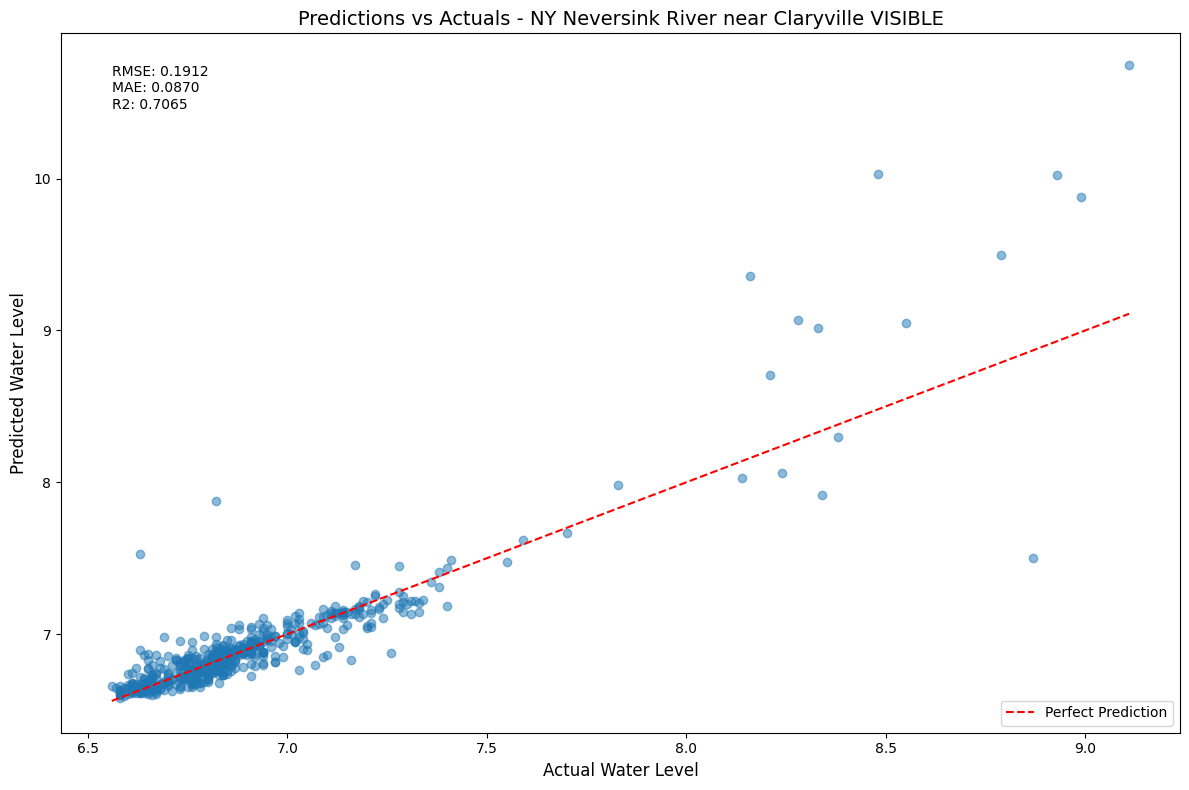

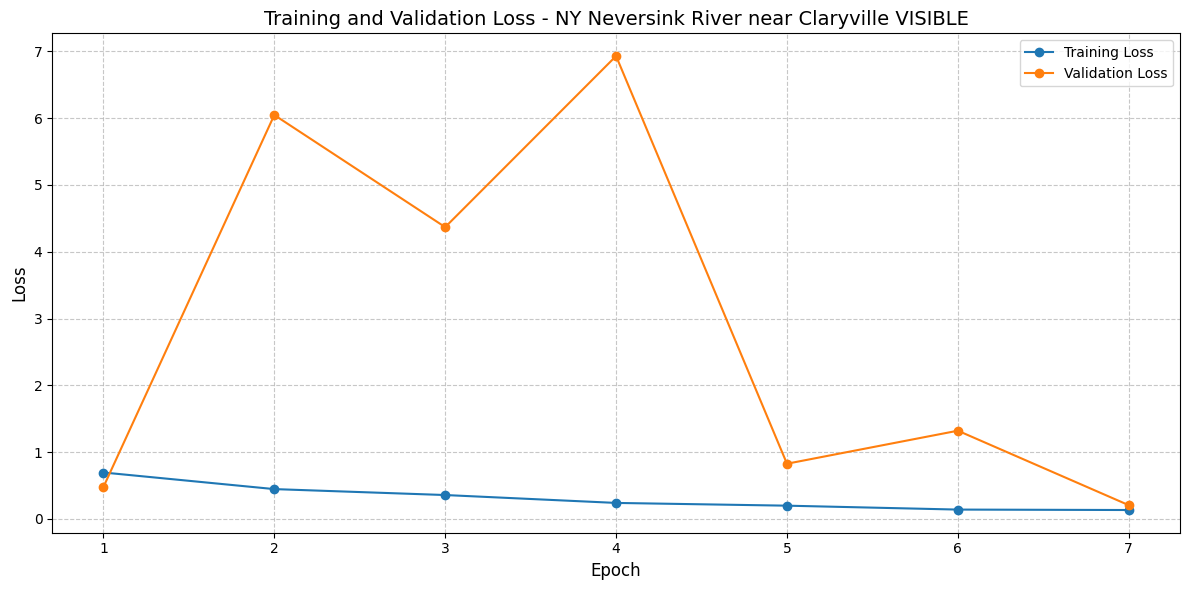


Uploading all results to S3...
Uploaded best_model_NY_Neversink_River_near_Claryville_VISIBLE.pth to s3://vims-ngwos/NY-Neversink-River-near-Claryville-VISIBLE/models/best_model_NY_Neversink_River_near_Claryville_VISIBLE.pth
Uploaded scaler_NY_Neversink_River_near_Claryville_VISIBLE.pkl to s3://vims-ngwos/NY-Neversink-River-near-Claryville-VISIBLE/models/scaler_NY_Neversink_River_near_Claryville_VISIBLE.pkl
Uploaded training_checkpoint_NY_Neversink_River_near_Claryville_VISIBLE.pth to s3://vims-ngwos/NY-Neversink-River-near-Claryville-VISIBLE/models/training_checkpoint_NY_Neversink_River_near_Claryville_VISIBLE.pth
Uploaded training_progress_NY_Neversink_River_near_Claryville_VISIBLE.json to s3://vims-ngwos/NY-Neversink-River-near-Claryville-VISIBLE/models/training_progress_NY_Neversink_River_near_Claryville_VISIBLE.json
Uploaded train_split_ny_neversink_river_near_claryville_visible.csv to s3://vims-ngwos/NY-Neversink-River-near-Claryville-VISIBLE/data-splits/train_split_ny_neversink

In [8]:
# Section 8: Execution script - Run this to start the training process
# Configure your settings here and execute to train the model

if __name__ == "__main__":  # FIXED: was 'if **name** == "__main__":'
    # Configuration flags - Modify these based on your needs
    USE_S3 = True  # Set to True to upload results to S3
    LOAD_SPLITS_FROM_S3 = False  # Set to True to load existing data splits from S3
    
    print("USGS Water Level Prediction Training")
    print("="*60)
    
    # Display configuration
    if USE_S3:
        print("S3 Integration: ENABLED")
        print(f"S3 Bucket: {S3_BUCKET_NAME}")
    else:
        print("S3 Integration: DISABLED (local only)")
    
    if LOAD_SPLITS_FROM_S3:
        print("Data Splits: Loading from S3")
    else:
        print("Data Splits: Creating new splits")
    
    print("="*60)
    
    # Execute main training function
    results = main(use_s3_for_results=USE_S3, load_splits_from_s3=LOAD_SPLITS_FROM_S3)
    
    # Display final results
    if results is not None:
        print("\n" + "="*60)
        print("TRAINING COMPLETED SUCCESSFULLY!")
        print("="*60)
        print(f"Site: {results['site_name']}")
        print(f"Best Epoch: {results['best_epoch'] + 1}")
        print(f"Final Test RMSE: {results['test_metrics']['rmse']:.4f}")
        print(f"Final Test MAE: {results['test_metrics']['mae']:.4f}")
        print(f"Final Test R2: {results['test_metrics']['r2']:.4f}")
        print(f"Training Time: {results['training_time']:.2f} seconds")
        
        site_safe = results['site_name'].replace(' ', '_')
        print(f"\nLocal Files Created:")
        print(f"- best_model_{site_safe}.pth")
        print(f"- scaler_{site_safe}.pkl")
        print(f"- test_results_{site_safe}.csv")
        print(f"- predictions_vs_actuals_{site_safe}.png")
        print(f"- loss_curves_{site_safe}.png")
        
        if USE_S3:
            print(f"\nAll results uploaded to S3 bucket: {S3_BUCKET_NAME}")
            s3_prefix = site_safe.replace('_', '-')
            print(f"S3 prefix: {s3_prefix}/")
    else:
        print("\n" + "="*60)
        print("TRAINING FAILED!")
        print("="*60)
        print("Common issues to check:")
        print("1. Run the USGS downloader script first to get images and data")
        print("2. Ensure 'image_metadata_with_usgs.csv' exists in site directory")
        print("3. Verify 'usgs_images' directory contains site folders")
        print("4. Check that images exist in the site folder")
        if USE_S3:
            print("5. Verify AWS credentials are configured")
            print("6. Ensure S3 bucket exists and has write permissions")

print("Execution script loaded successfully!")

In [9]:
# Add this code BEFORE your main() function call to clear GPU memory

import gc
import torch

def clear_gpu_memory():
    """Thoroughly clear GPU memory"""
    if torch.cuda.is_available():
        print("Clearing GPU memory...")
        
        # Clear all cached memory
        torch.cuda.empty_cache()
        
        # Force garbage collection
        gc.collect()
        
        # Get memory info
        allocated = torch.cuda.memory_allocated(0) / 1e9
        reserved = torch.cuda.memory_reserved(0) / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        print(f"GPU Memory after cleanup:")
        print(f"  Total: {total:.2f} GB")
        print(f"  Allocated: {allocated:.2f} GB") 
        print(f"  Reserved: {reserved:.2f} GB")
        print(f"  Free: {total - reserved:.2f} GB")
        
        return True
    else:
        print("CUDA not available")
        return False

# Call this before running your training
clear_gpu_memory()

# Then run your training
# results = main(use_s3_for_results=USE_S3, load_splits_from_s3=LOAD_SPLITS_FROM_S3)

Clearing GPU memory...
GPU Memory after cleanup:
  Total: 15.64 GB
  Allocated: 2.56 GB
  Reserved: 4.48 GB
  Free: 11.16 GB


True

In [10]:
# Check what processes are using GPU memory
import subprocess
import os

def check_gpu_usage():
    """Check GPU memory usage and processes"""
    try:
        # Run nvidia-smi to see GPU usage
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        print("=== GPU Usage ===")
        print(result.stdout)
        
        # Also check PyTorch's view of memory
        if torch.cuda.is_available():
            print("\n=== PyTorch GPU Memory ===")
            for i in range(torch.cuda.device_count()):
                print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
                print(f"  Allocated: {torch.cuda.memory_allocated(i) / 1e9:.2f} GB")
                print(f"  Reserved: {torch.cuda.memory_reserved(i) / 1e9:.2f} GB")
                print(f"  Max Allocated: {torch.cuda.max_memory_allocated(i) / 1e9:.2f} GB")
                
    except Exception as e:
        print(f"Could not check GPU usage: {e}")

# Run this to see what's using your GPU
check_gpu_usage()

=== GPU Usage ===
Wed Apr 29 18:37:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   32C    P0             31W /   70W |    4413MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------

In [11]:
# STEP 1: Complete GPU Memory Reset
# Run this FIRST before any other code

import gc
import torch

def complete_gpu_reset():
    """Thoroughly reset GPU memory state"""
    print("=== GPU Memory Reset ===")
    
    # Clear all cached memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        
        # Force garbage collection
        gc.collect()
        
        # Clear compilation cache if using torch.compile
        if hasattr(torch, '_dynamo'):
            torch._dynamo.reset()
        
        # Get memory info
        total_memory = torch.cuda.get_device_properties(0).total_memory
        allocated = torch.cuda.memory_allocated(0)
        reserved = torch.cuda.memory_reserved(0)
        
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Total Memory: {total_memory / 1e9:.2f} GB")
        print(f"Allocated: {allocated / 1e9:.2f} GB ({allocated/total_memory*100:.1f}%)")
        print(f"Reserved: {reserved / 1e9:.2f} GB ({reserved/total_memory*100:.1f}%)")
        print(f"Free: {(total_memory - reserved) / 1e9:.2f} GB")
        
        if reserved > total_memory * 0.1:  # More than 10% reserved
            print("⚠️  High reserved memory detected - restart kernel recommended")
            return False
        else:
            print("✅ GPU memory successfully reset")
            return True
    else:
        print("CUDA not available")
        return False

# Execute the reset
memory_cleared = complete_gpu_reset()

=== GPU Memory Reset ===
GPU: Tesla T4
Total Memory: 15.64 GB
Allocated: 2.56 GB (16.4%)
Reserved: 4.19 GB (26.8%)
Free: 11.44 GB
⚠️  High reserved memory detected - restart kernel recommended


In [ ]:
# STEP 2: If memory reset doesn't work, use these optimizations
# Modify your main() function with these memory-saving parameters

def main_memory_optimized(use_s3_for_results=True, load_splits_from_s3=False, auto_site=None):
    # Clear GPU memory at start
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        
    # MEMORY-OPTIMIZED PARAMETERS
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_img_size = 384          # Reduced from 512
    batch_size = 4               # Reduced from 8  
    learning_rate = 1e-4         # Reduced learning rate to compensate
    num_epochs = 10              # Increased epochs to compensate for smaller batch
    early_stop_patience = 4
    
    # DISABLE MEMORY-INTENSIVE FEATURES
    use_amp = False              # Disable mixed precision to save memory
    
    # Disable model compilation (saves compilation cache memory)
    compile_model = False
    
    print(f"MEMORY-OPTIMIZED SETTINGS:")
    print(f"Image Size: {input_img_size}x{input_img_size}")
    print(f"Batch Size: {batch_size}")
    print(f"Mixed Precision: {use_amp}")
    print(f"Model Compilation: {compile_model}")
    
    # Continue with rest of main() function but with these parameters...
    # [Rest of your main function code goes here with the modified parameters]

# ALTERNATIVE: Use gradient checkpointing to trade compute for memory
def enable_gradient_checkpointing(model):
    """Enable gradient checkpointing to save memory during backward pass"""
    for module in model.modules():
        if hasattr(module, 'gradient_checkpointing'):
            module.gradient_checkpointing = True
        elif hasattr(module, 'use_checkpoint'):
            module.use_checkpoint = True
    return model

# ALTERNATIVE: Process data in smaller chunks
def create_memory_efficient_dataloader(dataset, batch_size, **kwargs):
    """Create dataloader with memory-efficient settings"""
    return DataLoader(
        dataset, 
        batch_size=batch_size,
        num_workers=1,           # Reduced workers
        pin_memory=False,        # Disable pin memory
        persistent_workers=False, # Disable persistent workers
        prefetch_factor=1,       # Reduce prefetch
        **kwargs
    )

print("Memory optimization functions loaded!")

In [12]:
# STEP 3: Quick diagnostic and recovery commands
# Run these in separate cells to identify and fix the issue

# 1. CHECK CURRENT GPU USAGE
import subprocess
import torch

def diagnose_gpu_memory():
    """Comprehensive GPU memory diagnosis"""
    print("=== GPU MEMORY DIAGNOSIS ===")
    
    # Check nvidia-smi
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=10)
        print("NVIDIA-SMI Output:")
        print(result.stdout)
    except:
        print("Could not run nvidia-smi")
    
    # Check PyTorch memory
    if torch.cuda.is_available():
        print(f"\nPYTORCH MEMORY STATE:")
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
            print(f"  Allocated: {torch.cuda.memory_allocated(i) / 1e9:.3f} GB")
            print(f"  Reserved: {torch.cuda.memory_reserved(i) / 1e9:.3f} GB")
            print(f"  Max Allocated: {torch.cuda.max_memory_allocated(i) / 1e9:.3f} GB")
            print(f"  Max Reserved: {torch.cuda.max_memory_reserved(i) / 1e9:.3f} GB")

# 2. AGGRESSIVE MEMORY CLEANUP
def aggressive_cleanup():
    """Most aggressive cleanup possible without kernel restart"""
    print("=== AGGRESSIVE CLEANUP ===")
    
    # Delete all global variables that might hold tensors
    import sys
    global_vars_to_delete = []
    
    for name, obj in list(globals().items()):
        if hasattr(obj, '__class__'):
            class_name = obj.__class__.__name__
            if any(tensor_type in class_name.lower() for tensor_type in ['tensor', 'model', 'dataset', 'dataloader']):
                global_vars_to_delete.append(name)
    
    for var_name in global_vars_to_delete:
        if var_name in globals():
            print(f"Deleting global variable: {var_name}")
            del globals()[var_name]
    
    # Clear all caches
    import gc
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.reset_peak_memory_stats()
        
        # Clear compilation cache
        if hasattr(torch, '_dynamo'):
            torch._dynamo.reset()
            print("Cleared torch._dynamo cache")
    
    # Force garbage collection
    for _ in range(3):
        gc.collect()
    
    print("Aggressive cleanup completed")

# 3. SET MEMORY OPTIMIZATION ENVIRONMENT VARIABLES
def set_memory_optimizations():
    """Set environment variables for better memory management"""
    import os
    
    # PyTorch memory management
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    os.environ['TORCH_CUDNN_USE_HEURISTIC_MODE_B'] = '1'
    
    # Reduce memory fragmentation
    os.environ['CUDA_LAUNCH_BLOCKING'] = '0'
    
    print("Memory optimization environment variables set")
    print("Environment variables:")
    print(f"  PYTORCH_CUDA_ALLOC_CONF = {os.environ.get('PYTORCH_CUDA_ALLOC_CONF')}")
    print(f"  TORCH_CUDNN_USE_HEURISTIC_MODE_B = {os.environ.get('TORCH_CUDNN_USE_HEURISTIC_MODE_B')}")

# Run diagnostics
diagnose_gpu_memory()

# Try cleanup
aggressive_cleanup()

# Set optimizations
set_memory_optimizations()

# Check memory after cleanup
print("\n" + "="*50)
print("MEMORY STATE AFTER CLEANUP:")
diagnose_gpu_memory()

=== GPU MEMORY DIAGNOSIS ===
NVIDIA-SMI Output:
Wed Apr 29 18:38:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   32C    P0             31W /   70W |    4141MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
